In [19]:
import os
import numpy as np
import pickle
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.applications.xception import Xception, preprocess_input
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import matplotlib.pyplot as plt
from PIL import Image
import requests
from io import BytesIO
from nltk.translate.bleu_score import corpus_bleu


In [20]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [21]:
ZIP_PATH = '/content/drive/MyDrive/caption_data.zip'
WORKING_DIR = '/content/caption_data'

if not os.path.exists(WORKING_DIR):
    !unzip -q {ZIP_PATH} -d {WORKING_DIR}
    print("Unzipped successfully!")

IMAGE_DIR = os.path.join(WORKING_DIR, 'Images')
CAPTIONS_FILE = os.path.join(WORKING_DIR, 'captions.txt')

In [22]:
MODEL_PATH = "/content/drive/MyDrive/best_model.keras"
TOKENIZER_PATH = "/content/drive/MyDrive/tokenizer.pkl"

# Load model
model = load_model(MODEL_PATH)

# Load tokenizer
with open(TOKENIZER_PATH, "rb") as f:
    tokenizer = pickle.load(f)

max_length = 38


In [23]:
def load_and_clean_captions(mapping_file):
    df = pd.read_csv(mapping_file)
    mapping = {}

    for i, row in df.iterrows():
        img_name = row['image']
        caption = str(row['caption'])
        caption = caption.lower()
        caption = "".join([char for char in caption if char.isalpha() or char.isspace() or char.isnumeric()])
        caption = f"startseq {caption} endseq"

        if img_name not in mapping:
            mapping[img_name] = []

        mapping[img_name].append(caption)

    return mapping

captions_dict = load_and_clean_captions(CAPTIONS_FILE)
print(f"Loaded {len(captions_dict)} unique images.")

Loaded 8091 unique images.


In [24]:
xception_model = Xception(include_top=False, pooling="avg")

In [25]:
def extract_image_feature(image_path):
    """
    Extracts a 2048-dim feature vector from an image using Xception.
    """
    img = load_img(image_path, target_size=(299, 299))
    img = img_to_array(img)
    img = img.reshape((1, 299, 299, 3))
    img = preprocess_input(img)

    feature = xception_model.predict(img, verbose=0)
    return feature


In [26]:
def generate_caption(image_path, model, tokenizer, max_length, beam_width=3):
    feature = extract_image_feature(image_path)

    sequences = [[['startseq'], 0.0]]

    for _ in range(max_length):
        all_candidates = []

        for seq, score in sequences:
            if seq[-1] == 'endseq':
                all_candidates.append([seq, score])
                continue

            encoded = tokenizer.texts_to_sequences([' '.join(seq)])[0]
            padded = pad_sequences([encoded], maxlen=max_length, padding='post')

            preds = model.predict([feature, padded], verbose=0)[0]
            top_k = np.argsort(preds)[-beam_width:]

            for idx in top_k:
                word = tokenizer.index_word.get(idx)
                if word:
                    new_score = score - np.log(preds[idx] + 1e-10)
                    all_candidates.append([seq + [word], new_score])

        sequences = sorted(all_candidates, key=lambda x: x[1])[:beam_width]

        if all(seq[-1] == 'endseq' for seq, _ in sequences):
            break

    caption = sequences[0][0]
    caption = caption[1:-1] if 'endseq' in caption else caption[1:]
    return ' '.join(caption)


In [27]:
def caption_from_url(url):
    response = requests.get(url)
    img = Image.open(BytesIO(response.content)).convert("RGB")

    temp_path = "temp.jpg"
    img.save(temp_path)

    caption = generate_caption(temp_path, model, tokenizer, max_length)

    plt.imshow(img)
    plt.axis("off")
    plt.title(caption)
    plt.show()


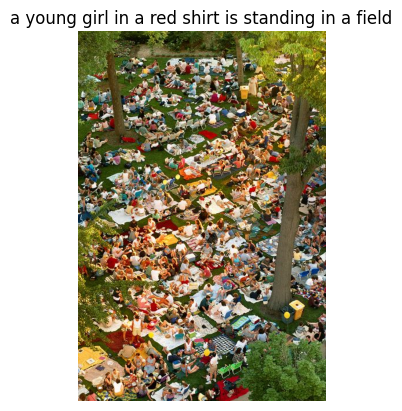

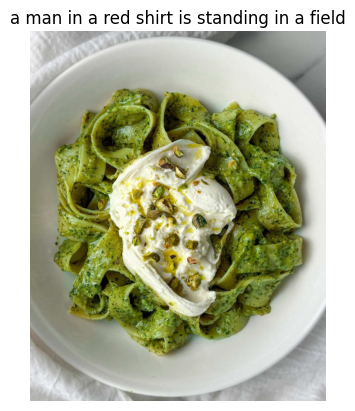

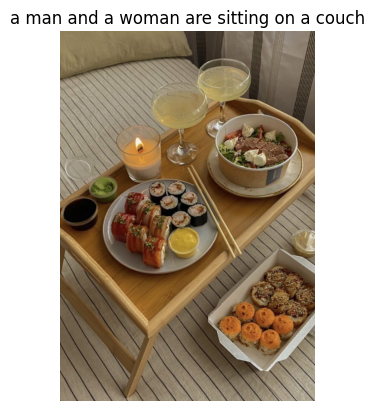

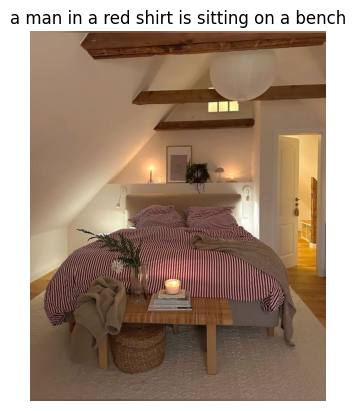

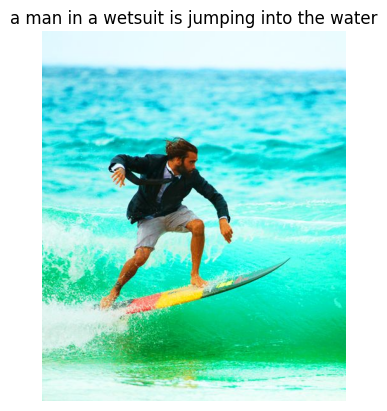

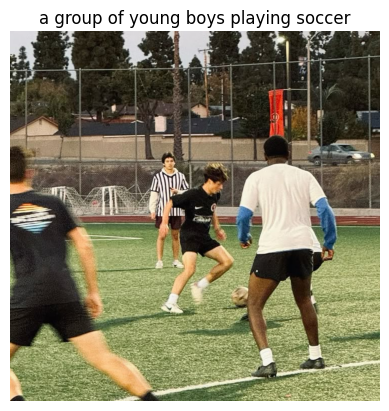

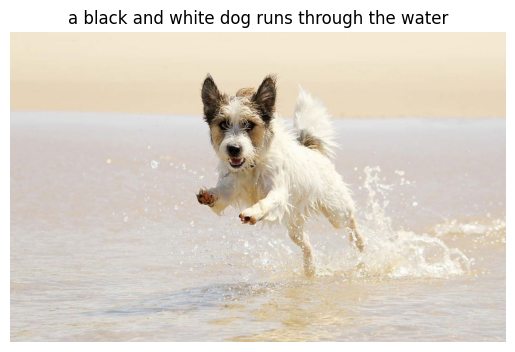

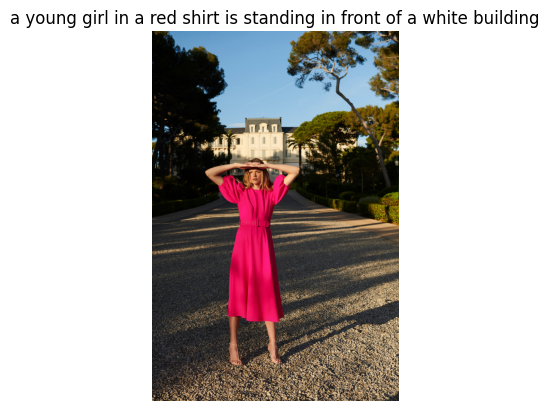

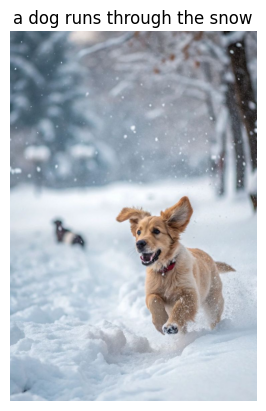

In [28]:
urls = [
    "https://i.pinimg.com/736x/a0/e3/33/a0e333e8c651723b61444cf48cf84e01.jpg", # ძალიან, არასწორი, ზედმეტად გადატვირთული ფოტოა
    "https://i.pinimg.com/1200x/90/19/aa/9019aab5cf1fdbad913b744e50256f87.jpg", # პატა, არასწორი
    "https://i.pinimg.com/736x/ea/5e/53/ea5e531a2c060eab721984f6ceb39d9a.jpg", # სუში, არასწორი
    "https://i.pinimg.com/736x/2a/0b/43/2a0b433a36fc10ebe99abea0f8faa083.jpg", # საწოლი, არასწორი

    "https://i.pinimg.com/736x/a4/6f/b0/a46fb05550e8b2131171ede0a361e6d6.jpg", # სერფინგი, მიდ


    "https://i.pinimg.com/736x/bd/13/d8/bd13d83bead308206ca70ccac80cb9bb.jpg", # ფეხბურთი, სწორი
    "https://i.pinimg.com/1200x/34/36/f0/3436f05001602a52fe0ab33b278b20b5.jpg", # ძაღლი წყალში, სწორი
    "https://www.beulahlondon.com/cdn/shop/files/23.04.25_BEULAH_SS23_026_131copy.jpg?v=1741796705&width=1000", # გოგო წითლში  სწორი
    "https://i.pinimg.com/736x/61/24/9a/61249ad221af526246d830e0eb292cd2.jpg" # ძაღლი თოვლში სწორი

]

for url in urls:
    caption_from_url(url)


In [29]:
def evaluate_model(model, image_keys, captions_dict, tokenizer, image_dir, limit=20):
    actual, predicted = [], []

    for i, key in enumerate(image_keys[:limit]):
        refs = [cap.split() for cap in captions_dict[key]]
        actual.append(refs)

        img_path = os.path.join(image_dir, key)
        yhat = generate_caption(img_path, model, tokenizer, max_length)
        predicted.append(yhat.split())

    print(f"BLEU-1: {corpus_bleu(actual, predicted, weights=(1,0,0,0)):.4f}")
    print(f"BLEU-2: {corpus_bleu(actual, predicted, weights=(0.5,0.5,0,0)):.4f}")


In [30]:
test_keys = list(captions_dict.keys())[int(len(captions_dict)*0.9):]
evaluate_model(model, test_keys, captions_dict, tokenizer, IMAGE_DIR)


BLEU-1: 0.4883
BLEU-2: 0.2962


Top 10 Content Words:
1. dog (8,136 occurrences)
2. man (7,265)
3. two (5,638)
4. white (3,940)
5. black (3,832)
6. boy (3,581)
7. woman (3,402)
8. girl (3,328)
9. wearing (3,062)
10. people (2,883)

Common Actions:
- running (2,073)
- playing (2,008)
- standing (1,787)
- jumping (1,472)

Common Settings:
- water (2,783)
- grass (1,622)
- snow (1,492)


##Missing Vocabulary Categories

**Indoor Environments:**
- Words like "room", "living room", "bedroom", "kitchen", "interior"

**Food-Related Terms:**
- "plate", "food", "dish", "meal", "pasta", "wine", "dining", "restaurant", "table setting"

**Objects and Furnishings:**
- "couch", "sofa", "bed", "pillow",

**Alternative Perspectives:**
- "overhead", "from above", "crowd"

---

## Why Successful Predictions Work

Images with accurate captions have these in comman:

1. **Outdoor settings** - heavily represented in training data
2. **People or dogs as main subjects** - most common entities (15,576+ combined mentions)
3. **Common actions** - running, playing, standing, jumping are well-learned
4. **Standard colors** - white, black, red, brown, blue dominate training vocabulary
5. **Ground-level perspective** - matches typical training data viewpoint
6. **Simple composition** - single clear subject performing one action

The model excels at these scenarios because they constitute the vast majority of training examples.

---

## Why Failed Predictions Occur

### Pattern Matching Errors

The model has learned these incorrect associations:

- **Indoor scenes with warm lighting** → "outdoor scene with person in red shirt"
- **Overhead view of dense objects** → "people in a field"
- **Any plate or surface with items** → defaults to familiar templates (people, outdoor scenes)

### Template Forcing

When encountering unfamiliar image types, the model forces predictions into its most frequently seen templates:

1. Person (man/woman/boy/girl) in colored shirt
2. Dog doing activity
3. Outdoor setting (field/water/grass/snow)
4. Common action (standing/playing/running)


## Training Metrics Interpretation

### Loss Progression
```
Epoch 1:  Training Loss: 7.23  |  Validation Loss: 4.98
Epoch 10: Training Loss: 4.02  |  Validation Loss: 4.09
Epoch 20: Training Loss: 3.79  |  Validation Loss: 3.98